# 01 - EDA avanzado y Feature Engineering

Este notebook construye un EDA profundo para justificar las variables que alimentan los dos modelos obligatorios del Taller 2 de Machine Learning I:

- **Modelo xG:** regresion logistica para estimar `P(gol | tiro)`.
- **Match Predictor:** regresion lineal para goles totales y regresion logistica multiclase para el resultado `H / D / A`.

El objetivo no es solo describir datos: el analisis busca convertir patrones futbolisticos en features defendibles, revisar riesgos de data leakage y exportar datasets procesados listos para entrenamiento reproducible.

## 1. Configuracion e imports

Se usan rutas relativas al repositorio. El notebook puede ejecutarse desde la raiz del proyecto o desde la carpeta `notebooks/`.

In [1]:
from __future__ import annotations

import ast
import json
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
from IPython.display import display
from sklearn.metrics import confusion_matrix


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "README.md").exists():
            return candidate
    return current


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
API_CACHE_DIR = DATA_DIR / "api_cache"

RAW_DATA_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)

BASE_URL = "https://premier.72-60-245-2.sslip.io"
ENDPOINTS = {
    "players": f"{BASE_URL}/export/players",
    "matches": f"{BASE_URL}/export/matches",
    "events": f"{BASE_URL}/export/events",
}

TEAM_NAME_MAP = {
    "Arsenal FC": "Arsenal",
    "Aston Villa FC": "Aston Villa",
    "Manchester City": "Man City",
    "Manchester United": "Man United",
    "Man Utd": "Man United",
    "Man Utd.": "Man United",
    "Nottm Forest": "Nottingham Forest",
    "Nott'm Forest": "Nottingham Forest",
    "Tottenham Hotspur": "Tottenham",
    "Spurs": "Tottenham",
    "Wolverhampton Wanderers": "Wolves",
    "Wolverhampton": "Wolves",
}

COLORS = {
    "ink": "#040608",
    "muted": "#6b7585",
    "emerald": "#10b981",
    "emerald_light": "#34d399",
    "indigo": "#6366f1",
    "amber": "#f59e0b",
    "rose": "#f43f5e",
    "blue": "#3b82f6",
    "surface": "#f5f6f8",
}

sns.set_theme(
    style="whitegrid",
    context="notebook",
    rc={
        "axes.facecolor": "#ffffff",
        "figure.facecolor": "#ffffff",
        "grid.color": "#e5e7eb",
        "axes.edgecolor": "#d1d5db",
        "axes.titleweight": "bold",
    },
)
PALETTE = [COLORS["emerald"], COLORS["indigo"], COLORS["amber"], COLORS["rose"], COLORS["blue"]]

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

def label_bars(ax, values, fmt="{:.1%}", orientation="vertical", padding=0.01):
    for patch, value in zip(ax.patches, values):
        if pd.isna(value):
            continue
        if orientation == "horizontal":
            width = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            ax.text(width + padding, y, fmt.format(value), ha="left", va="center", fontsize=9)
        else:
            height = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            ax.text(x, height + padding, fmt.format(value), ha="center", va="bottom", fontsize=9)

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\User\Desktop\TALLERPREMIER\PremierLeagueML


## 2. Carga de datos

Primero se intenta cargar `players`, `matches` y `events` desde archivos locales. Si falta alguno, se usa el endpoint `/export/...`. En todos los casos se guarda una copia en `data/raw/` para poder trabajar offline.

In [2]:
def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(col).strip().lower() for col in out.columns]
    return out


def load_dataset(name: str) -> tuple[pd.DataFrame, str]:
    local_path = DATA_DIR / f"{name}.csv"
    raw_path = RAW_DATA_DIR / f"{name}.csv"

    if local_path.exists():
        df = pd.read_csv(local_path)
        source = str(local_path.relative_to(PROJECT_ROOT))
    elif raw_path.exists():
        df = pd.read_csv(raw_path)
        source = str(raw_path.relative_to(PROJECT_ROOT))
    else:
        warnings.warn(f"No se encontro {name}.csv local. Se descargara desde {ENDPOINTS[name]}")
        df = pd.read_csv(ENDPOINTS[name])
        source = ENDPOINTS[name]

    df = normalize_columns(df)
    df.to_csv(raw_path, index=False)
    return df, source


players, players_source = load_dataset("players")
matches, matches_source = load_dataset("matches")
events, events_source = load_dataset("events")

dataset_overview = pd.DataFrame(
    [
        {"dataset": "players", "source": players_source, "rows": len(players), "columns": players.shape[1]},
        {"dataset": "matches", "source": matches_source, "rows": len(matches), "columns": matches.shape[1]},
        {"dataset": "events", "source": events_source, "rows": len(events), "columns": events.shape[1]},
    ]
)
display(dataset_overview)

for name, df in [("players", players), ("matches", matches), ("events", events)]:
    print(f"\n{name}: shape={df.shape}")
    print("Columnas principales:", list(df.columns[:18]))
    display(df.dtypes.reset_index().rename(columns={"index": "column", 0: "dtype"}).head(20))

,dataset,source,rows,columns
0,players,data\players.csv,822,37
1,matches,data\matches.csv,291,41
2,events,data\events.csv,444252,19



players: shape=(822, 37)
Columnas principales: ['id', 'first_name', 'second_name', 'web_name', 'team', 'team_short', 'position', 'price', 'status', 'total_points', 'minutes', 'starts', 'goals_scored', 'assists', 'clean_sheets', 'goals_conceded', 'yellow_cards', 'red_cards']


,column,dtype
0,id,int64
1,first_name,str
2,second_name,str
3,web_name,str
4,team,str
5,team_short,str
6,position,str
7,price,float64
8,status,str
9,total_points,int64



matches: shape=(291, 41)
Columnas principales: ['id', 'date', 'time', 'home_team', 'away_team', 'fthg', 'ftag', 'ftr', 'hthg', 'htag', 'htr', 'referee', 'hs', 'as_', 'hst', 'ast', 'hf', 'af']


,column,dtype
0,id,int64
1,date,str
2,time,str
3,home_team,str
4,away_team,str
5,fthg,int64
6,ftag,int64
7,ftr,str
8,hthg,int64
9,htag,int64



events: shape=(444252, 19)
Columnas principales: ['id', 'match_id', 'minute', 'second', 'period', 'event_type', 'outcome', 'team_name', 'player_name', 'player_id', 'x', 'y', 'end_x', 'end_y', 'goal_mouth_y', 'goal_mouth_z', 'is_touch', 'is_shot']


,column,dtype
0,id,int64
1,match_id,int64
2,minute,int64
3,second,float64
4,period,str
5,event_type,str
6,outcome,str
7,team_name,str
8,player_name,str
9,player_id,float64


**Insight accionable:** mantener copias en `data/raw/` permite reproducir el EDA aunque el API no este disponible. Esto tambien separa la capa cruda de los datasets procesados que se exportan al final.

## 3. Limpieza inicial

Se convierten fechas en formato `DD/MM/YYYY`, se normalizan nombres de equipos, se revisan nulos y duplicados, y se crea una tabla de calidad de datos. Para analisis espacial, se excluyen eventos sin ubicacion real.

In [3]:
def normalize_team_name(value: object) -> str:
    clean = str(value or "").strip()
    return TEAM_NAME_MAP.get(clean, clean)


def ensure_numeric(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


def warn_missing(df: pd.DataFrame, columns: list[str], frame_name: str) -> list[str]:
    missing = [col for col in columns if col not in df.columns]
    if missing:
        warnings.warn(f"{frame_name}: columnas faltantes: {missing}")
    return missing


players_clean = players.copy()
matches_clean = matches.copy()
events_clean = events.copy()

for frame, columns in [(players_clean, ["team"]), (matches_clean, ["home_team", "away_team"]), (events_clean, ["team_name"])]:
    for col in columns:
        if col in frame.columns:
            frame[col] = frame[col].map(normalize_team_name)

if "date" in matches_clean.columns:
    parsed_date = pd.to_datetime(matches_clean["date"].astype(str), format="%d/%m/%Y", errors="coerce")
    fallback_date = pd.to_datetime(matches_clean["date"].astype(str), dayfirst=True, errors="coerce")
    matches_clean["date"] = parsed_date.fillna(fallback_date)
else:
    warnings.warn("matches no tiene columna date; no se puede crear kickoff desde fecha.")

if {"date", "time"}.issubset(matches_clean.columns):
    matches_clean["kickoff"] = pd.to_datetime(
        matches_clean["date"].dt.strftime("%Y-%m-%d") + " " + matches_clean["time"].astype(str),
        errors="coerce",
    )
elif "date" in matches_clean.columns:
    matches_clean["kickoff"] = matches_clean["date"]

match_numeric_cols = [
    "fthg", "ftag", "hthg", "htag", "hs", "as_", "hst", "ast", "hf", "af", "hc", "ac",
    "hy", "ay", "hr", "ar", "b365h", "b365d", "b365a", "bwh", "bwd", "bwa",
    "maxh", "maxd", "maxa", "avgh", "avgd", "avga", "total_goals", "goal_diff",
]
event_numeric_cols = ["minute", "second", "x", "y", "end_x", "end_y", "goal_mouth_y", "goal_mouth_z", "is_touch", "is_shot", "is_goal"]

matches_clean = ensure_numeric(matches_clean, match_numeric_cols)
events_clean = ensure_numeric(events_clean, event_numeric_cols)

if "total_goals" not in matches_clean.columns and {"fthg", "ftag"}.issubset(matches_clean.columns):
    matches_clean["total_goals"] = matches_clean["fthg"] + matches_clean["ftag"]

if "ftr" not in matches_clean.columns and {"fthg", "ftag"}.issubset(matches_clean.columns):
    matches_clean["ftr"] = np.select(
        [matches_clean["fthg"] > matches_clean["ftag"], matches_clean["fthg"] == matches_clean["ftag"]],
        ["H", "D"],
        default="A",
    )

if "kickoff" in matches_clean.columns:
    matches_clean = matches_clean.sort_values(["kickoff", "id"], na_position="last").reset_index(drop=True)

events_spatial = events_clean.copy()
if {"x", "y"}.issubset(events_spatial.columns):
    events_spatial = events_spatial.dropna(subset=["x", "y"])
    events_spatial = events_spatial.loc[~((events_spatial["x"] == 0) & (events_spatial["y"] == 0))].copy()
else:
    warnings.warn("events no tiene x/y; se omiten analisis espaciales.")
    events_spatial = pd.DataFrame()

quality_summary = pd.DataFrame(
    [
        {
            "dataset": name,
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate_rows": int(df.duplicated().sum()),
            "missing_cells": int(df.isna().sum().sum()),
            "missing_pct": round(float(df.isna().mean().mean() * 100), 2),
        }
        for name, df in [("players", players_clean), ("matches", matches_clean), ("events", events_clean)]
    ]
)

if "kickoff" in matches_clean.columns:
    quality_summary.loc[quality_summary["dataset"] == "matches", "invalid_dates"] = int(matches_clean["kickoff"].isna().sum())

display(quality_summary)

print("Top nulos por dataset:")
for name, df in [("players", players_clean), ("matches", matches_clean), ("events", events_clean)]:
    nulls = df.isna().sum().sort_values(ascending=False).head(10)
    print(f"\n{name}")
    display(nulls[nulls > 0].to_frame("missing_count"))

print(f"Eventos espaciales validos: {len(events_spatial):,} de {len(events_clean):,}")

,dataset,rows,columns,duplicate_rows,missing_cells,missing_pct,invalid_dates
0,players,822,37,0,733,2.41,NaN
1,matches,291,42,0,0,0.00,0.0
2,events,444252,19,0,1182033,14.00,NaN


Top nulos por dataset:

players


,missing_count
news,515
chance_of_playing_next_round,218



matches


,missing_count



events


,missing_count
goal_mouth_z,437054
goal_mouth_y,437054
end_x,148867
end_y,148867
player_id,4629
player_name,4629
second,933


Eventos espaciales validos: 433,808 de 444,252


**Insight accionable:** los eventos `Start`, `End`, tarjetas o sustituciones suelen traer `x=0, y=0`; si se mantienen en mapas o heatmaps distorsionan la cancha. Por eso los analisis espaciales usan solo eventos con coordenadas reales.

## 4. EDA de tiros para el modelo xG

El modelo xG trabaja a nivel de tiro. Se filtra `is_shot == true`, se enriquecen los tiros con qualifiers cuando estan disponibles y se construyen features geometricas y contextuales.

In [4]:
def load_shot_qualifier_cache() -> pd.DataFrame:
    cache_path = API_CACHE_DIR / "shot_events_with_qualifiers.json"
    if cache_path.exists():
        try:
            return normalize_columns(pd.read_json(cache_path))
        except ValueError:
            with cache_path.open(encoding="utf-8") as file:
                return normalize_columns(pd.DataFrame(json.load(file)))

    if "qualifiers" in events_clean.columns:
        return events_clean.loc[events_clean.get("is_shot", 0) == 1, ["id", "qualifiers"]].copy()

    try:
        warnings.warn("No existe cache local de qualifiers. Se consultara /events?is_shot=true.")
        response = requests.get(f"{BASE_URL}/events?is_shot=true&limit=10000&format=json", timeout=120)
        response.raise_for_status()
        payload = response.json()
        rows = payload.get("events", payload) if isinstance(payload, dict) else payload
        API_CACHE_DIR.mkdir(parents=True, exist_ok=True)
        with cache_path.open("w", encoding="utf-8") as file:
            json.dump(rows, file, ensure_ascii=True, indent=2)
        return normalize_columns(pd.DataFrame(rows))
    except Exception as exc:
        warnings.warn(f"No se pudieron cargar qualifiers de tiros: {exc}")
        return pd.DataFrame()


def parse_json_like(value):
    if isinstance(value, list):
        return value
    if isinstance(value, dict):
        return [value]
    if pd.isna(value):
        return []
    if isinstance(value, str):
        value = value.strip()
        if not value:
            return []
        for parser in (json.loads, ast.literal_eval):
            try:
                parsed = parser(value)
                if isinstance(parsed, list):
                    return parsed
                if isinstance(parsed, dict):
                    return [parsed]
            except Exception:
                continue
        return [value]
    return [value]


def qualifier_names(value) -> list[str]:
    names: list[str] = []
    for item in parse_json_like(value):
        if isinstance(item, dict):
            item_type = item.get("type", {})
            if isinstance(item_type, dict) and item_type.get("displayName"):
                names.append(str(item_type["displayName"]))
        elif item:
            names.append(str(item))
    return names


def qualifiers_to_text(value) -> str:
    tokens: list[str] = []
    for item in parse_json_like(value):
        if isinstance(item, dict):
            item_type = item.get("type", {})
            if isinstance(item_type, dict) and item_type.get("displayName"):
                tokens.append(str(item_type["displayName"]))
            if item.get("value") not in [None, ""]:
                tokens.append(str(item["value"]))
        elif item:
            tokens.append(str(item))
    return " ".join(tokens).lower()


def compact_text(series: pd.Series) -> pd.Series:
    return series.fillna("").str.lower().str.replace(r"[^a-z0-9]+", "", regex=True)


def add_shot_features(shots_df: pd.DataFrame) -> pd.DataFrame:
    shots_out = shots_df.copy()
    shots_out = ensure_numeric(shots_out, ["x", "y", "is_goal"])
    shots_out["is_goal"] = shots_out["is_goal"].fillna(0).astype(int)
    shots_out["qualifier_text"] = shots_out.get("qualifiers", pd.Series(index=shots_out.index, dtype=object)).apply(qualifiers_to_text)
    shots_out["qualifier_names"] = shots_out.get("qualifiers", pd.Series(index=shots_out.index, dtype=object)).apply(qualifier_names)
    qtext = compact_text(shots_out["qualifier_text"])

    # Formula exigida por el taller: arco rival en (100, 50).
    shots_out["shot_distance"] = np.sqrt((100 - shots_out["x"]) ** 2 + (50 - shots_out["y"]) ** 2)
    shots_out["shot_angle"] = np.arctan2(np.abs(50 - shots_out["y"]), 100 - shots_out["x"])

    flag_patterns = {
        "is_big_chance": ["bigchance"],
        "is_header": ["head", "headed"],
        "is_right_foot": ["rightfoot"],
        "is_left_foot": ["leftfoot"],
        "is_penalty": ["penalty"],
        "is_volley": ["volley"],
        "first_touch": ["firsttouch"],
        "from_corner": ["fromcorner"],
        "is_counter": ["fastbreak", "counterattack", "counter"],
    }
    for col, patterns in flag_patterns.items():
        pattern = "|".join(patterns)
        shots_out[col] = qtext.str.contains(pattern, regex=True, na=False).astype(int)

    shots_out["body_part"] = np.select(
        [
            shots_out["is_header"].eq(1),
            shots_out["is_right_foot"].eq(1),
            shots_out["is_left_foot"].eq(1),
        ],
        ["Head", "Right foot", "Left foot"],
        default="Other",
    )

    shots_out["shot_zone"] = np.select(
        [
            qtext.str.contains("smallbox", na=False),
            qtext.str.contains("boxcentre|boxcenter|boxleft|boxright", regex=True, na=False),
            qtext.str.contains("outofbox", na=False),
        ],
        ["SmallBox", "Box", "OutOfBox"],
        default="Unknown",
    )
    return shots_out


required_shot_columns = ["is_shot", "x", "y", "is_goal"]
warn_missing(events_clean, required_shot_columns, "events")

if "is_shot" in events_clean.columns:
    shots = events_clean.loc[events_clean["is_shot"].fillna(0).astype(int) == 1].copy()
else:
    shots = pd.DataFrame()
    warnings.warn("No se puede construir shots porque events no tiene is_shot.")

shot_qualifiers = load_shot_qualifier_cache()
if not shots.empty and not shot_qualifiers.empty and {"id", "qualifiers"}.issubset(shot_qualifiers.columns):
    if "qualifiers" in shots.columns:
        shots = shots.merge(shot_qualifiers[["id", "qualifiers"]], on="id", how="left", suffixes=("", "_api"))
        shots["qualifiers"] = shots["qualifiers"].where(shots["qualifiers"].notna(), shots["qualifiers_api"])
        shots = shots.drop(columns=["qualifiers_api"], errors="ignore")
    else:
        shots = shots.merge(shot_qualifiers[["id", "qualifiers"]], on="id", how="left")
elif "qualifiers" not in shots.columns:
    shots["qualifiers"] = np.nan

if {"match_id", "id"}.issubset(shots.columns) and "id" in matches_clean.columns:
    match_context_cols = [col for col in ["id", "kickoff", "home_team", "away_team", "fthg", "ftag"] if col in matches_clean.columns]
    shots = shots.merge(
        matches_clean[match_context_cols].rename(columns={"id": "match_id"}),
        on="match_id",
        how="left",
        suffixes=("", "_match"),
    )

shots = add_shot_features(shots)
shots_spatial = shots.dropna(subset=["x", "y"]).copy()
shots_spatial = shots_spatial.loc[~((shots_spatial["x"] == 0) & (shots_spatial["y"] == 0))].copy()

xg_features_created = [
    "shot_distance", "shot_angle", "is_big_chance", "is_header", "is_right_foot", "is_left_foot",
    "is_penalty", "is_volley", "first_touch", "from_corner", "is_counter",
]

display(shots[xg_features_created + ["is_goal", "body_part", "shot_zone"]].head())
print(f"Tiros totales: {len(shots):,}")
print(f"Tiros con ubicacion valida: {len(shots_spatial):,}")
print(f"Goles en tiros: {int(shots['is_goal'].sum()):,}")
print(f"Conversion global: {shots['is_goal'].mean():.3%}")

,shot_distance,shot_angle,is_big_chance,is_header,is_right_foot,is_left_foot,is_penalty,is_volley,first_touch,from_corner,is_counter,is_goal,body_part,shot_zone
0,29.798154,0.678410,0,0,1,0,0,0,0,0,0,0,Right foot,Box
1,23.601907,0.914584,0,0,0,1,0,0,0,0,0,0,Left foot,Box
2,8.614523,0.058074,1,1,0,0,0,0,1,1,0,0,Head,Box
3,10.208330,0.511856,1,0,1,0,0,0,1,0,0,0,Right foot,Box
4,10.257680,1.050441,0,1,0,0,0,0,1,1,0,0,Head,SmallBox


Tiros totales: 7,198
Tiros con ubicacion valida: 7,198
Goles en tiros: 807
Conversion global: 11.211%


**Insight accionable:** las features xG combinan geometria (`shot_distance`, `shot_angle`) con contexto del remate (`BigChance`, penal, pie/cabeza, contraataque). Esto permite que la regresion logistica aprenda algo mas informativo que la tasa base de conversion.

### 4.1 Distribucion de goles vs no goles

C:\Users\User\AppData\Local\Temp\ipykernel_19616\368312095.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=goal_counts.index, y=goal_counts.values, palette=[COLORS["muted"], COLORS["emerald"]], ax=ax)


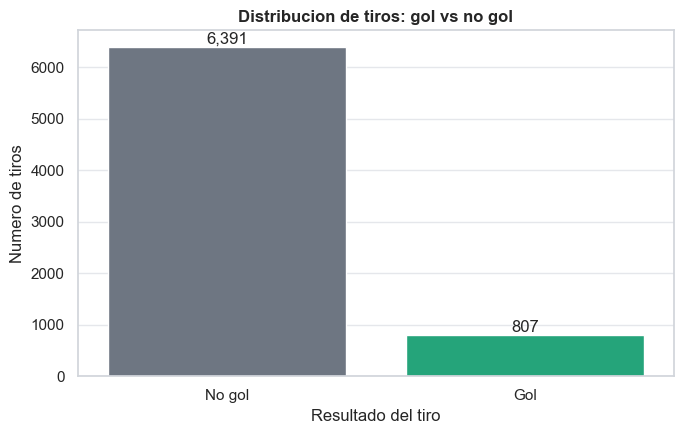

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
goal_counts = shots["is_goal"].map({0: "No gol", 1: "Gol"}).value_counts().reindex(["No gol", "Gol"])
sns.barplot(x=goal_counts.index, y=goal_counts.values, palette=[COLORS["muted"], COLORS["emerald"]], ax=ax)
ax.set_title("Distribucion de tiros: gol vs no gol")
ax.set_xlabel("Resultado del tiro")
ax.set_ylabel("Numero de tiros")
for i, value in enumerate(goal_counts.values):
    ax.text(i, value, f"{int(value):,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

**Insight accionable:** el target esta fuertemente desbalanceado: la mayoria de tiros no terminan en gol. Para el modelo xG no basta mirar accuracy; se deben revisar precision, recall, F1 y AUC.

### 4.2 Tasa de conversion de tiros

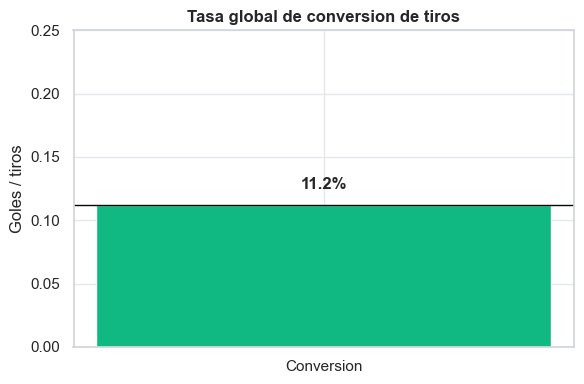

In [6]:
conversion_rate = shots["is_goal"].mean()
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["Conversion"], [conversion_rate], color=COLORS["emerald"], width=0.45)
ax.axhline(conversion_rate, color=COLORS["ink"], linewidth=1)
ax.set_ylim(0, max(0.25, conversion_rate * 1.8))
ax.set_title("Tasa global de conversion de tiros")
ax.set_ylabel("Goles / tiros")
ax.text(0, conversion_rate + 0.01, f"{conversion_rate:.1%}", ha="center", va="bottom", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

**Insight accionable:** esta tasa es el baseline empirico del xG. Cualquier feature seleccionada debe ayudar a explicar por que algunos tiros se apartan de esta probabilidad promedio.

### 4.2.1 Baseline naive del modelo xG

Como el target esta desbalanceado, el baseline naive consiste en predecir siempre `no gol`. Este baseline suele tener accuracy alta, pero no identifica ningun gol; por eso el modelo xG debe evaluarse tambien con precision, recall, F1 y AUC.

In [7]:
xg_naive_baseline_accuracy = 1 - conversion_rate
xg_naive_baseline = pd.DataFrame([
    {
        "baseline": "Siempre no gol",
        "accuracy": xg_naive_baseline_accuracy,
        "recall_gol": 0.0,
        "precision_gol": 0.0,
        "comentario": "Accuracy alto por desbalance, pero no detecta goles.",
    }
])
display(xg_naive_baseline)

,baseline,accuracy,recall_gol,precision_gol,comentario
0,Siempre no gol,0.887886,0.0,0.0,"Accuracy alto por desbalance, pero no detecta ..."


### 4.3 Histogramas de coordenadas x/y de los tiros

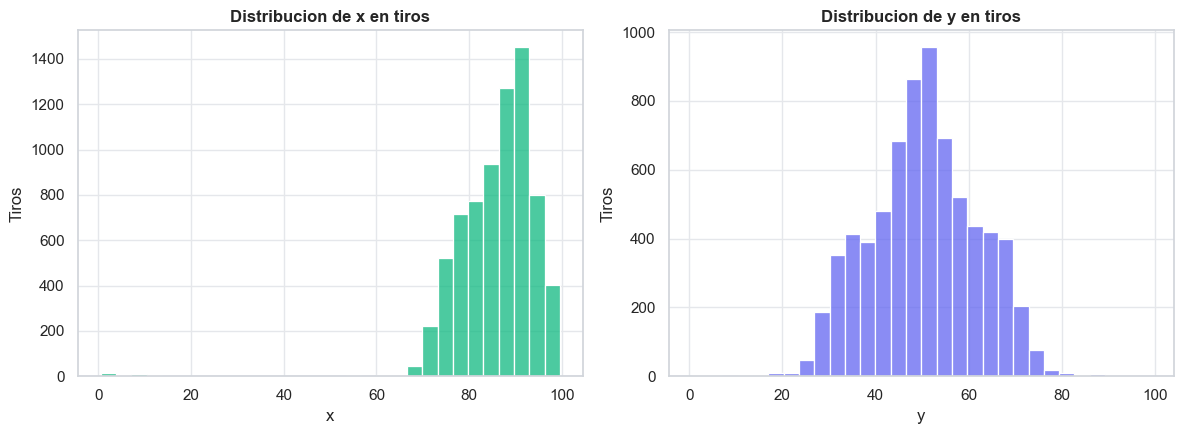

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(shots_spatial["x"], bins=30, color=COLORS["emerald"], ax=axes[0])
axes[0].set_title("Distribucion de x en tiros")
axes[0].set_xlabel("x")
axes[0].set_ylabel("Tiros")
sns.histplot(shots_spatial["y"], bins=30, color=COLORS["indigo"], ax=axes[1])
axes[1].set_title("Distribucion de y en tiros")
axes[1].set_xlabel("y")
axes[1].set_ylabel("Tiros")
plt.tight_layout()
plt.show()

**Insight accionable:** la concentracion de tiros hacia valores altos de `x` confirma que la cercania al arco rival debe entrar en el modelo. La dispersion en `y` justifica medir el angulo y no solo la distancia.

### 4.4 Shot map en cancha

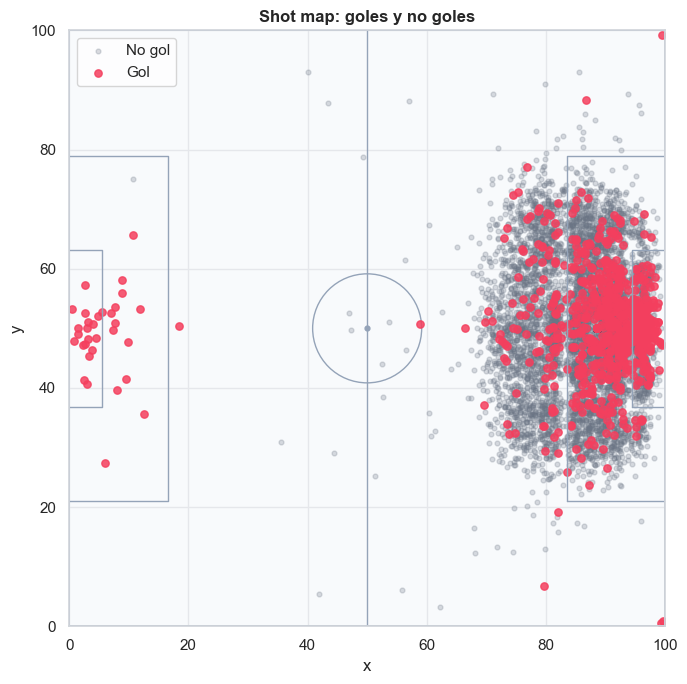

In [9]:
def draw_pitch(ax):
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_aspect("equal")
    ax.set_facecolor("#f8fafc")
    line_color = "#94a3b8"
    ax.plot([0, 100, 100, 0, 0], [0, 0, 100, 100, 0], color=line_color, linewidth=1.2)
    ax.axvline(50, color=line_color, linewidth=1)
    center_circle = plt.Circle((50, 50), 9.15, fill=False, color=line_color, linewidth=1)
    ax.add_patch(center_circle)
    ax.scatter([50], [50], color=line_color, s=12)
    ax.plot([83.5, 100, 100, 83.5, 83.5], [21.1, 21.1, 78.9, 78.9, 21.1], color=line_color, linewidth=1)
    ax.plot([94.5, 100, 100, 94.5, 94.5], [36.8, 36.8, 63.2, 63.2, 36.8], color=line_color, linewidth=1)
    ax.plot([0, 16.5, 16.5, 0], [21.1, 21.1, 78.9, 78.9], color=line_color, linewidth=1)
    ax.plot([0, 5.5, 5.5, 0], [36.8, 36.8, 63.2, 63.2], color=line_color, linewidth=1)
    ax.set_xlabel("x")
    ax.set_ylabel("y")


fig, ax = plt.subplots(figsize=(10, 7))
draw_pitch(ax)
no_goals = shots_spatial.loc[shots_spatial["is_goal"] == 0]
goals = shots_spatial.loc[shots_spatial["is_goal"] == 1]
ax.scatter(no_goals["x"], no_goals["y"], s=12, alpha=0.25, color=COLORS["muted"], label="No gol")
ax.scatter(goals["x"], goals["y"], s=28, alpha=0.85, color=COLORS["rose"], label="Gol")
ax.set_title("Shot map: goles y no goles")
ax.legend(loc="upper left")
plt.tight_layout()
plt.show()

**Insight accionable:** los goles se agrupan en zonas cercanas y centradas. Esta evidencia apoya incluir `shot_distance`, `shot_angle` y variables de zona en el modelo xG.

### 4.5 Heatmap de tiros

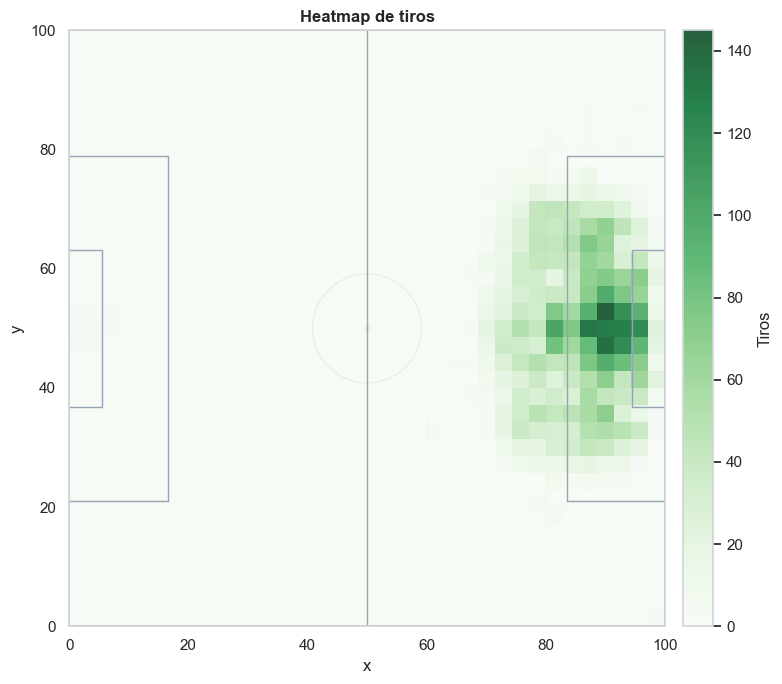

In [10]:
fig, ax = plt.subplots(figsize=(10, 7))
draw_pitch(ax)
h = ax.hist2d(shots_spatial["x"], shots_spatial["y"], bins=35, range=[[0, 100], [0, 100]], cmap="Greens", alpha=0.85)
ax.set_title("Heatmap de tiros")
fig.colorbar(h[3], ax=ax, fraction=0.035, pad=0.02, label="Tiros")
plt.tight_layout()
plt.show()

**Insight accionable:** el volumen de tiros no se distribuye de forma uniforme; las zonas de mayor frecuencia pueden mejorar la calibracion del xG si se combinan con conversion real.

### 4.6 Heatmap de goles

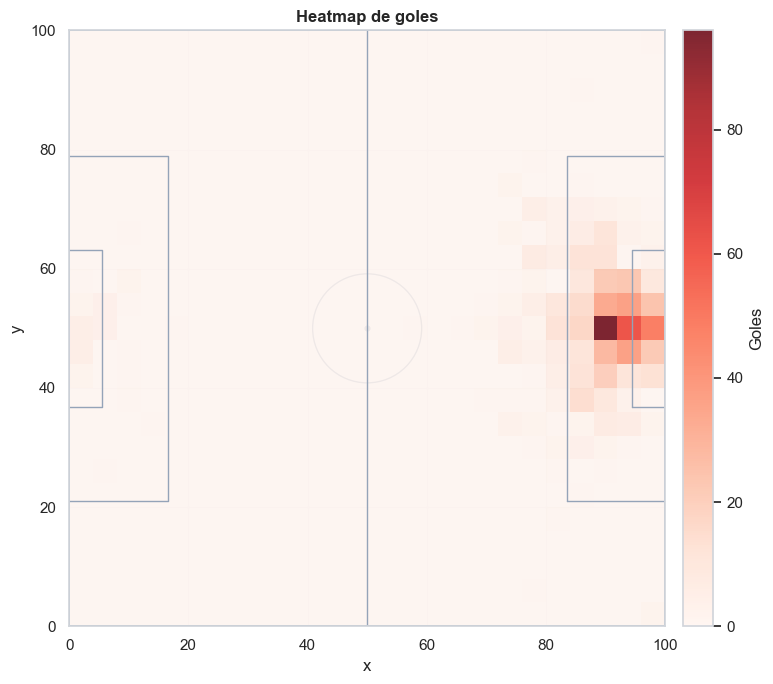

In [11]:
fig, ax = plt.subplots(figsize=(10, 7))
draw_pitch(ax)
goal_spatial = shots_spatial.loc[shots_spatial["is_goal"] == 1]
h = ax.hist2d(goal_spatial["x"], goal_spatial["y"], bins=25, range=[[0, 100], [0, 100]], cmap="Reds", alpha=0.85)
ax.set_title("Heatmap de goles")
fig.colorbar(h[3], ax=ax, fraction=0.035, pad=0.02, label="Goles")
plt.tight_layout()
plt.show()

**Insight accionable:** comparar heatmap de tiros contra heatmap de goles muestra que no toda zona con mucho volumen produce la misma amenaza. Por eso la variable de zona debe validarse con tasa de conversion.

### 4.7 Distribucion de distancia al arco

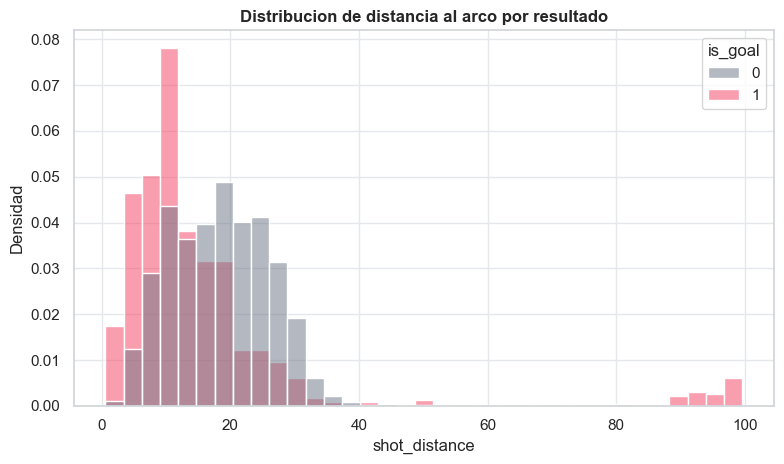

In [12]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(data=shots_spatial, x="shot_distance", hue="is_goal", bins=35, stat="density", common_norm=False, palette={0: COLORS["muted"], 1: COLORS["rose"]}, ax=ax)
ax.set_title("Distribucion de distancia al arco por resultado")
ax.set_xlabel("shot_distance")
ax.set_ylabel("Densidad")
handles, labels = ax.get_legend_handles_labels()
if handles:
    ax.legend(handles, ["No gol", "Gol"], title="Resultado")
plt.tight_layout()
plt.show()

**Insight accionable:** los goles aparecen con mayor densidad a distancias cortas. `shot_distance` debe ser una feature base de la regresion logistica xG.

### 4.8 Distancia al arco vs probabilidad de gol

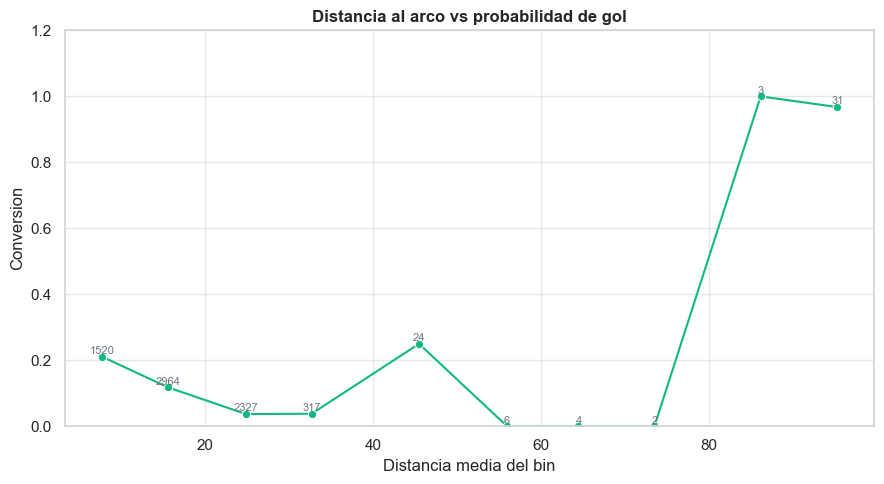

,mean_distance,conversion_rate,shots
0,7.664980,0.211184,1520
1,15.549937,0.117746,2964
2,24.834660,0.036957,2327
3,32.649403,0.037855,317
4,45.447277,0.250000,24
5,55.932859,0.000000,6
6,64.440847,0.000000,4
7,73.491317,0.000000,2
8,86.145779,1.000000,3
9,95.268830,0.967742,31


In [13]:
distance_bins = pd.cut(shots_spatial["shot_distance"], bins=10, duplicates="drop")
distance_profile = (
    shots_spatial.groupby(distance_bins, observed=False)
    .agg(mean_distance=("shot_distance", "mean"), conversion_rate=("is_goal", "mean"), shots=("is_goal", "size"))
    .dropna()
    .reset_index(drop=True)
)

fig, ax1 = plt.subplots(figsize=(9, 5))
sns.lineplot(data=distance_profile, x="mean_distance", y="conversion_rate", marker="o", color=COLORS["emerald"], ax=ax1)
ax1.set_title("Distancia al arco vs probabilidad de gol")
ax1.set_xlabel("Distancia media del bin")
ax1.set_ylabel("Conversion")
ax1.set_ylim(0, max(0.45, distance_profile["conversion_rate"].max() * 1.2))
for _, row in distance_profile.iterrows():
    ax1.text(row["mean_distance"], row["conversion_rate"] + 0.008, int(row["shots"]), ha="center", fontsize=8, color=COLORS["muted"])
plt.tight_layout()
plt.show()
display(distance_profile)

**Insight accionable:** la probabilidad de gol cae al aumentar la distancia. Este patron monotono facilita que una regresion logistica capture una relacion interpretable.

### 4.9 Angulo al arco vs probabilidad de gol

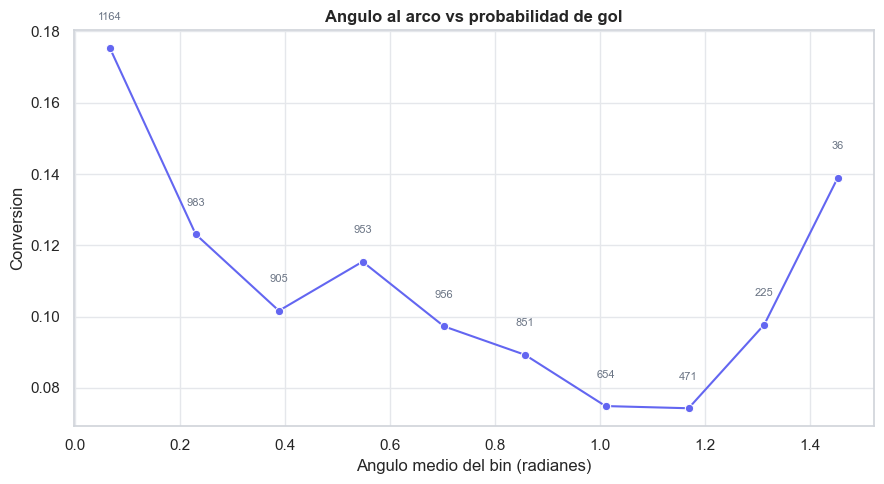

,mean_angle,conversion_rate,shots
0,0.066940,0.175258,1164
1,0.230232,0.123093,983
2,0.388702,0.101657,905
3,0.548068,0.115425,953
4,0.703219,0.097280,956
5,0.857363,0.089307,851
6,1.010869,0.074924,654
7,1.169075,0.074310,471
8,1.313328,0.097778,225
9,1.453042,0.138889,36


In [14]:
angle_bins = pd.cut(shots_spatial["shot_angle"], bins=10, duplicates="drop")
angle_profile = (
    shots_spatial.groupby(angle_bins, observed=False)
    .agg(mean_angle=("shot_angle", "mean"), conversion_rate=("is_goal", "mean"), shots=("is_goal", "size"))
    .dropna()
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.lineplot(data=angle_profile, x="mean_angle", y="conversion_rate", marker="o", color=COLORS["indigo"], ax=ax)
ax.set_title("Angulo al arco vs probabilidad de gol")
ax.set_xlabel("Angulo medio del bin (radianes)")
ax.set_ylabel("Conversion")
for _, row in angle_profile.iterrows():
    ax.text(row["mean_angle"], row["conversion_rate"] + 0.008, int(row["shots"]), ha="center", fontsize=8, color=COLORS["muted"])
plt.tight_layout()
plt.show()
display(angle_profile)

**Insight accionable:** el angulo agrega informacion distinta a la distancia porque diferencia tiros centrados de tiros laterales. Por eso se incluye como feature independiente en xG.

### 4.10 Conversion por BigChance

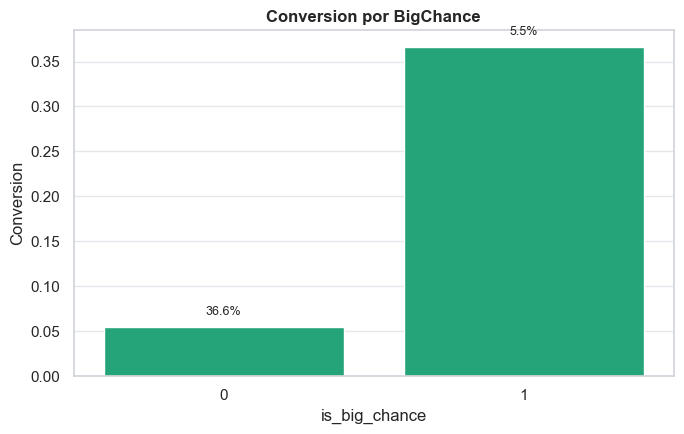

,is_big_chance,shots,goals,conversion_rate
1,1,1321,484,0.366389
0,0,5877,323,0.054960


In [15]:
def conversion_table(df: pd.DataFrame, column: str, min_count: int = 0) -> pd.DataFrame:
    table = (
        df.groupby(column, dropna=False)
        .agg(shots=("is_goal", "size"), goals=("is_goal", "sum"), conversion_rate=("is_goal", "mean"))
        .reset_index()
    )
    table = table.loc[table["shots"] >= min_count].sort_values("conversion_rate", ascending=False)
    return table


big_chance_table = conversion_table(shots, "is_big_chance")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=big_chance_table, x="is_big_chance", y="conversion_rate", color=COLORS["emerald"], ax=ax)
ax.set_title("Conversion por BigChance")
ax.set_xlabel("is_big_chance")
ax.set_ylabel("Conversion")
label_bars(ax, big_chance_table["conversion_rate"], fmt="{:.1%}")
plt.tight_layout()
plt.show()
display(big_chance_table)

**Insight accionable:** `BigChance` aumenta claramente la probabilidad de gol; por lo tanto se incluye como feature central del modelo xG.

### 4.11 Conversion por penal

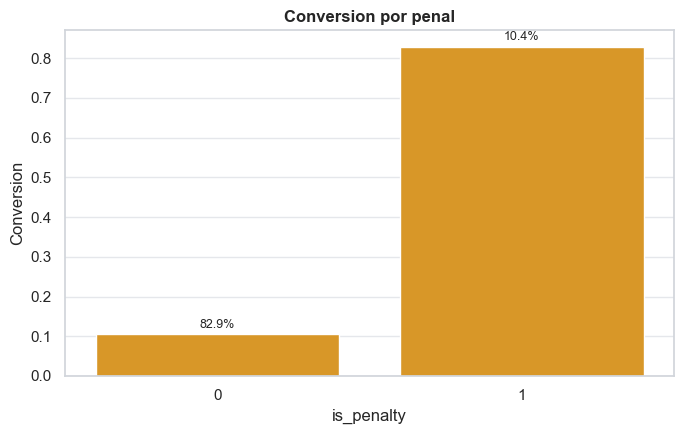

,is_penalty,shots,goals,conversion_rate
1,1,76,63,0.828947
0,0,7122,744,0.104465


In [16]:
penalty_table = conversion_table(shots, "is_penalty")
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=penalty_table, x="is_penalty", y="conversion_rate", color=COLORS["amber"], ax=ax)
ax.set_title("Conversion por penal")
ax.set_xlabel("is_penalty")
ax.set_ylabel("Conversion")
label_bars(ax, penalty_table["conversion_rate"], fmt="{:.1%}")
plt.tight_layout()
plt.show()
display(penalty_table)

**Insight accionable:** el penal es una situacion de tiro con probabilidad muy diferente al resto. Debe entrar como indicador para evitar que la distancia al arco explique sola un caso especial.

### 4.12 Conversion por parte del cuerpo

C:\Users\User\AppData\Local\Temp\ipykernel_19616\1248255796.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=body_table, x="body_part", y="conversion_rate", palette=PALETTE, ax=ax)
C:\Users\User\AppData\Local\Temp\ipykernel_19616\1248255796.py:3: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  sns.barplot(data=body_table, x="body_part", y="conversion_rate", palette=PALETTE, ax=ax)


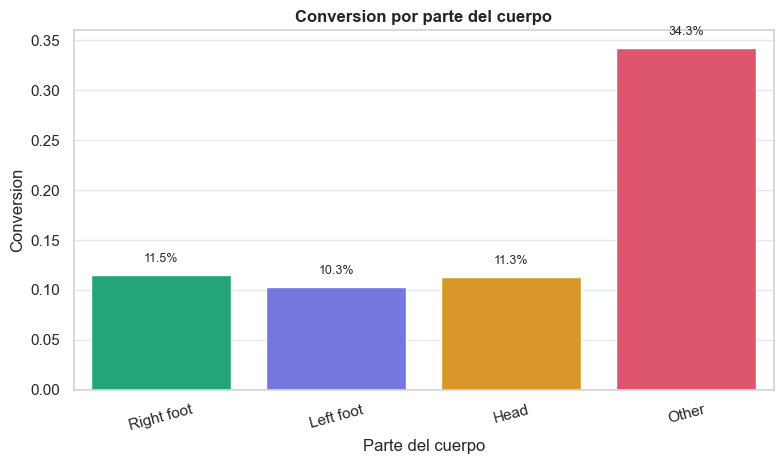

,body_part,shots,goals,conversion_rate
3,Right foot,3555,410,0.115331
1,Left foot,2256,232,0.102837
0,Head,1352,153,0.113166
2,Other,35,12,0.342857


In [17]:
body_table = conversion_table(shots, "body_part").sort_values("shots", ascending=False)
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.barplot(data=body_table, x="body_part", y="conversion_rate", palette=PALETTE, ax=ax)
ax.set_title("Conversion por parte del cuerpo")
ax.set_xlabel("Parte del cuerpo")
ax.set_ylabel("Conversion")
label_bars(ax, body_table["conversion_rate"], fmt="{:.1%}")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()
display(body_table)

**Insight accionable:** cabeza, pie derecho, pie izquierdo y otros remates no tienen la misma conversion. Las variables `is_header`, `is_right_foot` e `is_left_foot` capturan esta diferencia tecnica.

### 4.13 Conversion por zona del disparo

C:\Users\User\AppData\Local\Temp\ipykernel_19616\3255551605.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=zone_table, x="shot_zone", y="conversion_rate", palette=PALETTE, ax=ax)
C:\Users\User\AppData\Local\Temp\ipykernel_19616\3255551605.py:6: UserWarning: The palette list has more values (5) than needed (3), which may not be intended.
  sns.barplot(data=zone_table, x="shot_zone", y="conversion_rate", palette=PALETTE, ax=ax)


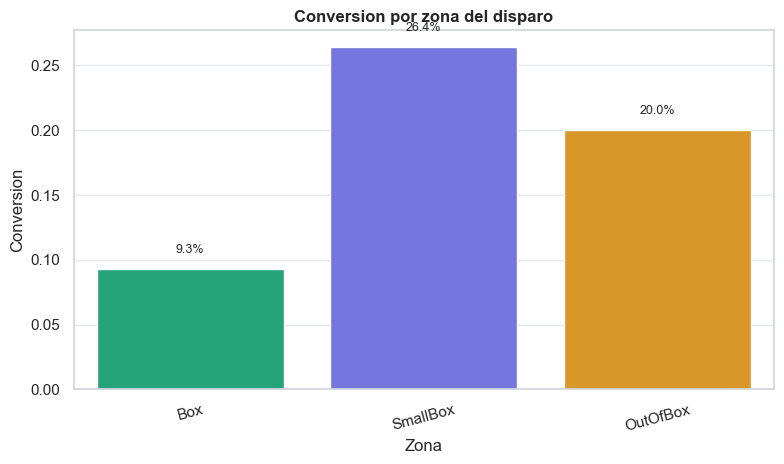

,shot_zone,shots,goals,conversion_rate
0,Box,6341,588,0.092730
2,SmallBox,807,213,0.263941
1,OutOfBox,20,4,0.200000


In [18]:
zone_table = conversion_table(shots.loc[shots["shot_zone"] != "Unknown"], "shot_zone").sort_values("shots", ascending=False)
if zone_table.empty:
    warnings.warn("No hay zonas de disparo disponibles en qualifiers.")
else:
    fig, ax = plt.subplots(figsize=(8, 4.8))
    sns.barplot(data=zone_table, x="shot_zone", y="conversion_rate", palette=PALETTE, ax=ax)
    ax.set_title("Conversion por zona del disparo")
    ax.set_xlabel("Zona")
    ax.set_ylabel("Conversion")
    label_bars(ax, zone_table["conversion_rate"], fmt="{:.1%}")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()
display(zone_table)

**Insight accionable:** la zona del tiro resume ubicacion y tipo de ocasion. Si la zona esta disponible, puede reforzar o complementar distancia y angulo en xG.

### 4.14 Top 15 qualifiers mas frecuentes en tiros

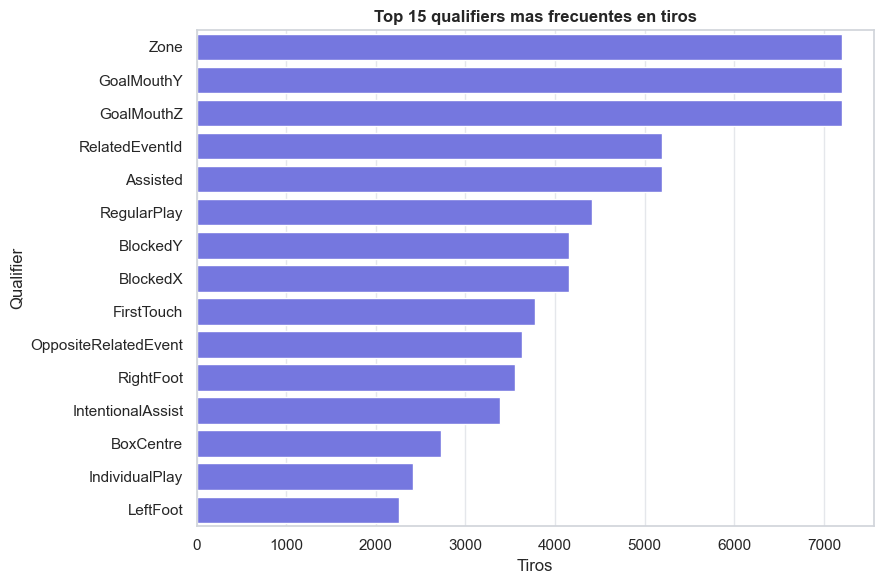

,qualifier,shots
0,Zone,7198
1,GoalMouthY,7198
2,GoalMouthZ,7198
3,RelatedEventId,5191
4,Assisted,5191
5,RegularPlay,4417
6,BlockedY,4154
7,BlockedX,4154
8,FirstTouch,3777
9,OppositeRelatedEvent,3626


In [19]:
qualifier_long = shots[["id", "is_goal", "qualifier_names"]].explode("qualifier_names")
qualifier_long = qualifier_long.dropna(subset=["qualifier_names"])
qualifier_long["qualifier_names"] = qualifier_long["qualifier_names"].astype(str)
qualifier_long = qualifier_long.rename(columns={"qualifier_names": "qualifier"})

top_qualifiers = qualifier_long["qualifier"].value_counts().head(15).reset_index()
top_qualifiers.columns = ["qualifier", "shots"]

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=top_qualifiers, y="qualifier", x="shots", color=COLORS["indigo"], ax=ax)
ax.set_title("Top 15 qualifiers mas frecuentes en tiros")
ax.set_xlabel("Tiros")
ax.set_ylabel("Qualifier")
plt.tight_layout()
plt.show()
display(top_qualifiers)

**Insight accionable:** los qualifiers frecuentes son candidatos naturales a features porque tienen suficiente soporte estadistico. Los muy raros se revisan con cuidado para no sobreajustar.

### 4.15 Qualifiers con mayor tasa de conversion, minimo 20 tiros

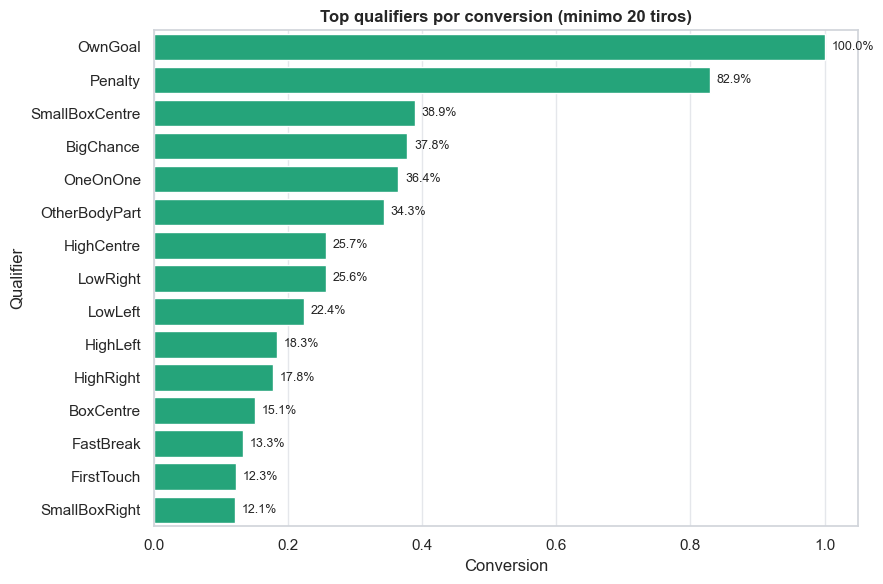

,qualifier,shots,goals,conversion_rate
0,OwnGoal,33,33,1.000000
1,Penalty,76,63,0.828947
2,SmallBoxCentre,435,169,0.388506
3,BigChance,1282,484,0.377535
4,OneOnOne,129,47,0.364341
5,OtherBodyPart,35,12,0.342857
6,HighCentre,265,68,0.256604
7,LowRight,812,208,0.256158
8,LowLeft,1006,225,0.223658
9,HighLeft,405,74,0.182716


In [20]:
qualifier_conversion = (
    qualifier_long.groupby("qualifier")
    .agg(shots=("is_goal", "size"), goals=("is_goal", "sum"), conversion_rate=("is_goal", "mean"))
    .query("shots >= 20")
    .sort_values("conversion_rate", ascending=False)
    .head(15)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(data=qualifier_conversion, y="qualifier", x="conversion_rate", color=COLORS["emerald"], ax=ax)
ax.set_title("Top qualifiers por conversion (minimo 20 tiros)")
ax.set_xlabel("Conversion")
ax.set_ylabel("Qualifier")
label_bars(ax, qualifier_conversion["conversion_rate"], fmt="{:.1%}", orientation="horizontal")
plt.tight_layout()
plt.show()
display(qualifier_conversion)

**Insight accionable:** al exigir minimo 20 tiros se reduce ruido de muestras pequenas. Los qualifiers con alta conversion y soporte suficiente son mejores candidatos para ampliar el modelo xG.

## 5. EDA de partidos para Match Predictor

El Match Predictor opera a nivel partido: primero predice goles totales con regresion lineal y luego el resultado `H/D/A` con regresion logistica multiclase.

In [21]:
required_match_columns = ["fthg", "ftag", "ftr", "total_goals"]
warn_missing(matches_clean, required_match_columns, "matches")

match_eda = matches_clean.copy()
if "total_goals" not in match_eda.columns and {"fthg", "ftag"}.issubset(match_eda.columns):
    match_eda["total_goals"] = match_eda["fthg"] + match_eda["ftag"]

display(match_eda.head())
print(f"Partidos: {len(match_eda):,}")
print(f"Goles totales: {int(match_eda['total_goals'].sum()) if 'total_goals' in match_eda.columns else 'NA'}")

,id,date,time,home_team,away_team,fthg,ftag,ftr,hthg,htag,htr,referee,hs,as_,hst,ast,hf,af,hc,ac,hy,ay,hr,ar,b365h,b365d,b365a,bwh,bwd,bwa,maxh,maxd,maxa,avgh,avgd,avga,total_goals,goal_diff,implied_prob_h,implied_prob_d,implied_prob_a,kickoff
0,1,2025-08-15,20:00,Liverpool,Bournemouth,4,2,H,1,0,H,A Taylor,19,10,10,3,7,10,6,7,1,2,0,0,1.30,6.00,8.50,1.32,5.5,7.50,1.34,6.50,9.5,1.31,5.96,8.31,6,2,0.769,0.167,0.118,2025-08-15 20:00:00
1,2,2025-08-16,12:30,Aston Villa,Newcastle,0,0,D,0,0,D,C Pawson,3,16,3,3,13,11,3,6,1,1,1,0,2.25,3.50,2.90,2.30,3.6,2.87,2.38,3.75,3.1,2.30,3.56,2.94,0,0,0.444,0.286,0.345,2025-08-16 12:30:00
2,3,2025-08-16,15:00,Brighton,Fulham,1,1,D,0,0,D,S Barrott,10,7,4,2,16,15,4,3,3,3,0,0,1.91,3.60,4.00,1.90,3.6,3.90,1.95,3.75,4.0,1.92,3.62,3.91,2,0,0.524,0.278,0.250,2025-08-16 15:00:00
3,4,2025-08-16,15:00,Sunderland,West Ham,3,0,H,0,0,D,R Jones,10,12,5,4,8,10,5,7,0,1,0,0,3.25,3.40,2.25,3.10,3.4,2.25,3.25,3.50,2.3,3.17,3.38,2.26,3,3,0.308,0.294,0.444,2025-08-16 15:00:00
4,5,2025-08-16,15:00,Tottenham,Burnley,3,0,H,1,0,H,M Oliver,16,14,6,4,14,8,6,5,0,0,0,0,1.38,4.75,8.50,1.39,4.8,8.00,1.40,5.00,9.5,1.37,4.80,8.30,3,3,0.725,0.211,0.118,2025-08-16 15:00:00


Partidos: 291
Goles totales: 807


### 5.1 Distribucion de resultados H/D/A

C:\Users\User\AppData\Local\Temp\ipykernel_19616\737861492.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=result_counts.index, y=result_counts.values, palette=[COLORS["emerald"], COLORS["amber"], COLORS["indigo"]], ax=ax)


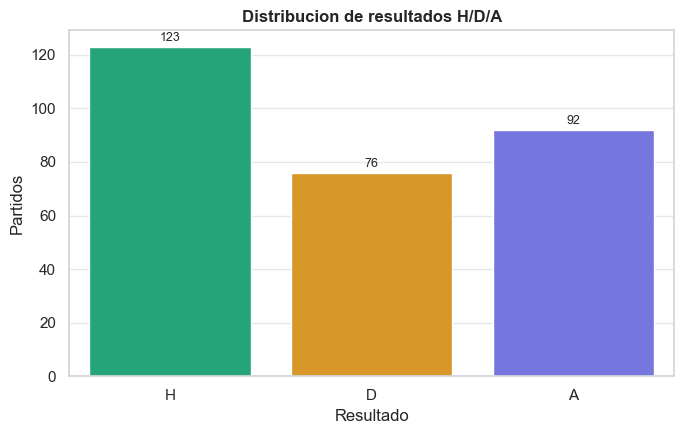

,matches
ftr,
H,123
D,76
A,92


In [22]:
result_counts = match_eda["ftr"].value_counts().reindex(["H", "D", "A"]).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=result_counts.index, y=result_counts.values, palette=[COLORS["emerald"], COLORS["amber"], COLORS["indigo"]], ax=ax)
ax.set_title("Distribucion de resultados H/D/A")
ax.set_xlabel("Resultado")
ax.set_ylabel("Partidos")
label_bars(ax, result_counts.values, fmt="{:,.0f}", padding=1)
plt.tight_layout()
plt.show()
display(result_counts.to_frame("matches"))

**Insight accionable:** la clase empate suele ser menos separable que local o visitante. La regresion logistica multiclase debe evaluarse con matriz de confusion, no solo accuracy.

### 5.2 Distribucion de goles totales por partido

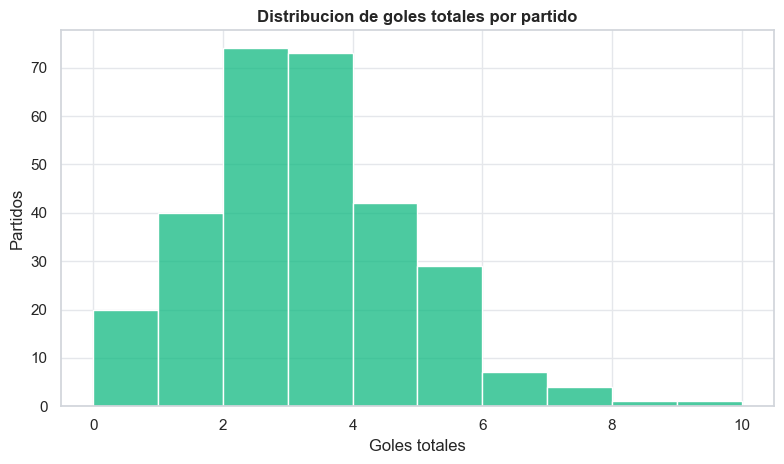

In [23]:
fig, ax = plt.subplots(figsize=(8, 4.8))
sns.histplot(match_eda["total_goals"], bins=range(0, int(match_eda["total_goals"].max()) + 2), color=COLORS["emerald"], ax=ax)
ax.set_title("Distribucion de goles totales por partido")
ax.set_xlabel("Goles totales")
ax.set_ylabel("Partidos")
plt.tight_layout()
plt.show()

**Insight accionable:** los goles totales son una variable discreta y concentrada en pocos valores. Para regresion lineal conviene revisar residuos y no asumir que todos los errores tienen el mismo costo futbolistico.

### 5.3 Goles locales vs goles visitantes

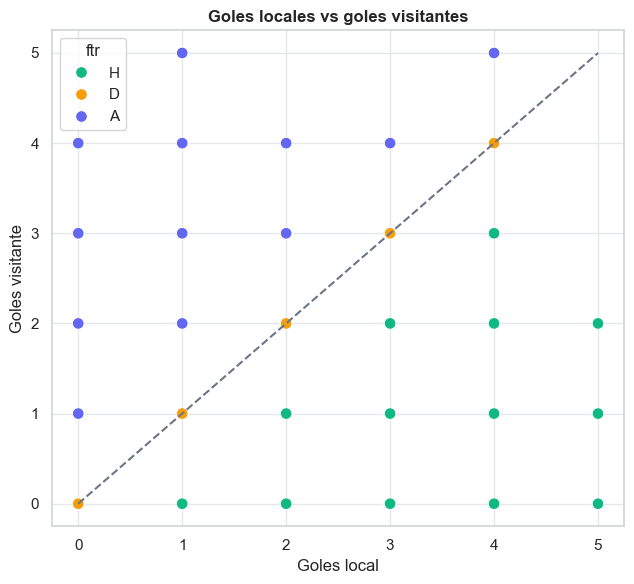

In [24]:
fig, ax = plt.subplots(figsize=(6.5, 6))
sns.scatterplot(data=match_eda, x="fthg", y="ftag", hue="ftr", palette={"H": COLORS["emerald"], "D": COLORS["amber"], "A": COLORS["indigo"]}, s=70, ax=ax)
ax.set_title("Goles locales vs goles visitantes")
ax.set_xlabel("Goles local")
ax.set_ylabel("Goles visitante")
ax.plot([0, max(match_eda["fthg"].max(), match_eda["ftag"].max())], [0, max(match_eda["fthg"].max(), match_eda["ftag"].max())], color=COLORS["muted"], linestyle="--")
plt.tight_layout()
plt.show()

**Insight accionable:** el resultado H/D/A se define por la diferencia entre goles locales y visitantes. Features que anticipen fortaleza relativa local-visitante son mas utiles que features absolutas aisladas.

### 5.4 Porcentaje de home wins, draws y away wins

C:\Users\User\AppData\Local\Temp\ipykernel_19616\1205918370.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=result_rates, x="result", y="rate", palette=[COLORS["emerald"], COLORS["amber"], COLORS["indigo"]], ax=ax)


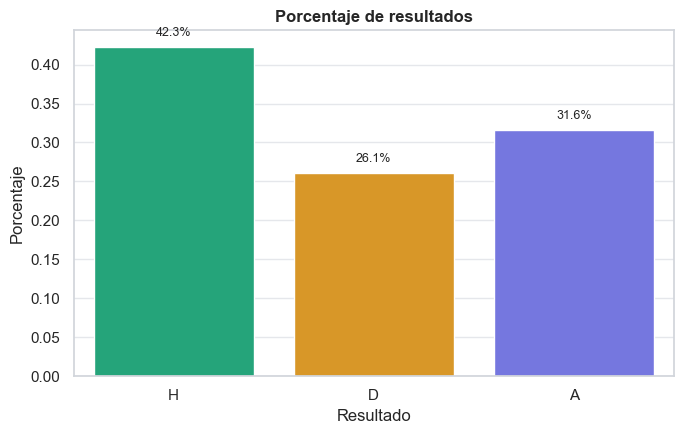

,result,rate
0,H,0.422680
1,D,0.261168
2,A,0.316151


In [25]:
result_rates = (result_counts / result_counts.sum()).reset_index()
result_rates.columns = ["result", "rate"]
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(data=result_rates, x="result", y="rate", palette=[COLORS["emerald"], COLORS["amber"], COLORS["indigo"]], ax=ax)
ax.set_title("Porcentaje de resultados")
ax.set_xlabel("Resultado")
ax.set_ylabel("Porcentaje")
label_bars(ax, result_rates["rate"], fmt="{:.1%}")
plt.tight_layout()
plt.show()
display(result_rates)

**Insight accionable:** estas proporciones son el baseline de clase para la clasificacion. Si un modelo solo replica la clase mayoritaria, no estaria superando informacion trivial.

### 5.5 Over/Under 2.5 goles

C:\Users\User\AppData\Local\Temp\ipykernel_19616\2316588232.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ou_counts.index, y=ou_counts.values, palette=[COLORS["blue"], COLORS["rose"]], ax=ax)


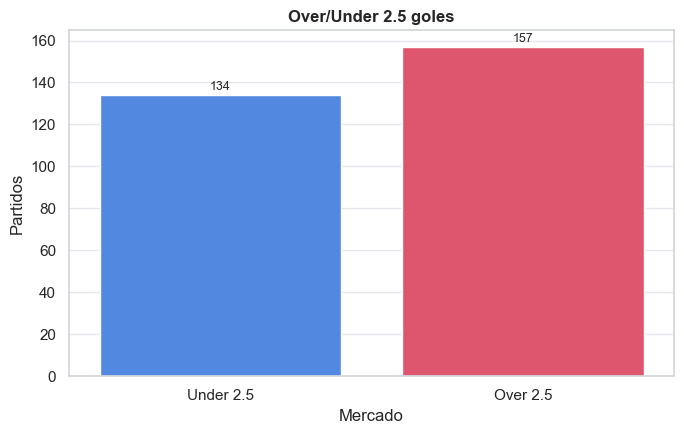

,rate
over_2_5,
Under 2.5,0.460481
Over 2.5,0.539519


In [26]:
match_eda["over_2_5"] = np.where(match_eda["total_goals"] > 2.5, "Over 2.5", "Under 2.5")
ou_counts = match_eda["over_2_5"].value_counts().reindex(["Under 2.5", "Over 2.5"])
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.barplot(x=ou_counts.index, y=ou_counts.values, palette=[COLORS["blue"], COLORS["rose"]], ax=ax)
ax.set_title("Over/Under 2.5 goles")
ax.set_xlabel("Mercado")
ax.set_ylabel("Partidos")
label_bars(ax, ou_counts.values, fmt="{:,.0f}", padding=1)
plt.tight_layout()
plt.show()
display((ou_counts / ou_counts.sum()).to_frame("rate"))

**Insight accionable:** el corte 2.5 ayuda a interpretar la distribucion de goles y a validar si las features prepartido capturan partidos abiertos o cerrados.

### 5.6 Relacion entre odds de Bet365 y resultado real

C:\Users\User\AppData\Local\Temp\ipykernel_19616\3521189846.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=match_eda, x="ftr", y="b365_actual_odds", order=["H", "D", "A"], palette=[COLORS["emerald"], COLORS["amber"], COLORS["indigo"]], ax=ax)


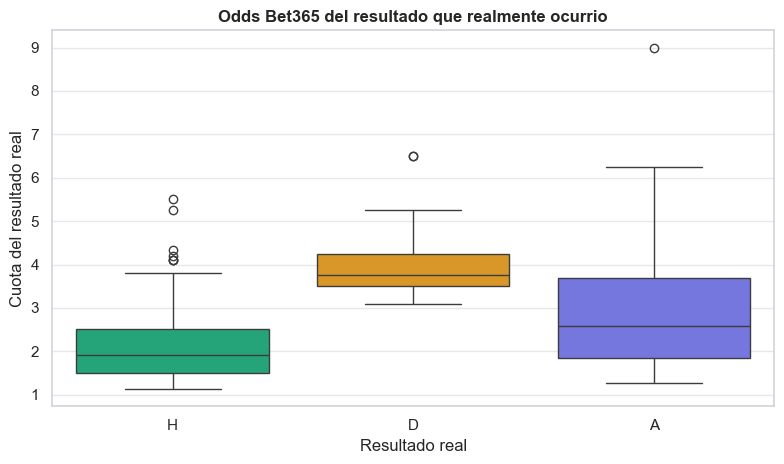

,count,mean,std,min,25%,50%,75%,max
ftr,,,,,,,,
A,92.0,2.909891,1.391046,1.27,1.8375,2.575,3.7000,9.0
D,76.0,3.961184,0.693494,3.10,3.5000,3.750,4.2325,6.5
H,123.0,2.160569,0.883282,1.13,1.5000,1.910,2.5250,5.5


In [27]:
odds_cols = ["b365h", "b365d", "b365a"]
if all(col in match_eda.columns for col in odds_cols):
    match_eda["b365_actual_odds"] = np.select(
        [match_eda["ftr"].eq("H"), match_eda["ftr"].eq("D"), match_eda["ftr"].eq("A")],
        [match_eda["b365h"], match_eda["b365d"], match_eda["b365a"]],
        default=np.nan,
    )
    fig, ax = plt.subplots(figsize=(8, 4.8))
    sns.boxplot(data=match_eda, x="ftr", y="b365_actual_odds", order=["H", "D", "A"], palette=[COLORS["emerald"], COLORS["amber"], COLORS["indigo"]], ax=ax)
    ax.set_title("Odds Bet365 del resultado que realmente ocurrio")
    ax.set_xlabel("Resultado real")
    ax.set_ylabel("Cuota del resultado real")
    plt.tight_layout()
    plt.show()
    display(match_eda.groupby("ftr")["b365_actual_odds"].describe())
else:
    warnings.warn("No existen todas las columnas B365H/B365D/B365A.")

**Insight accionable:** las odds condensan informacion prepartido del mercado. Deben ser features validas, pero tambien benchmark: el modelo debe justificar que agrega valor sobre Bet365.

### 5.7 Favoritos Bet365 vs resultado real

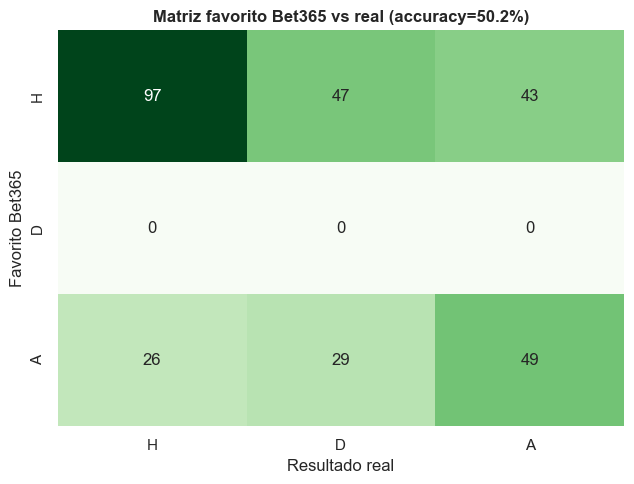

Resultado real,H,D,A
Favorito Bet365,,,
H,97,47,43
D,0,0,0
A,26,29,49


Accuracy Bet365: 50.172%


In [28]:
bet365_accuracy = None
if all(col in match_eda.columns for col in odds_cols):
    odds_to_result = {"b365h": "H", "b365d": "D", "b365a": "A"}
    match_eda["bet365_pred"] = match_eda[odds_cols].idxmin(axis=1).map(odds_to_result)
    favorite_crosstab = pd.crosstab(match_eda["bet365_pred"], match_eda["ftr"], rownames=["Favorito Bet365"], colnames=["Resultado real"]).reindex(index=["H", "D", "A"], columns=["H", "D", "A"], fill_value=0)
    bet365_accuracy = float((match_eda["bet365_pred"] == match_eda["ftr"]).mean())

    fig, ax = plt.subplots(figsize=(6.5, 5))
    sns.heatmap(favorite_crosstab, annot=True, fmt="d", cmap="Greens", cbar=False, ax=ax)
    ax.set_title(f"Matriz favorito Bet365 vs real (accuracy={bet365_accuracy:.1%})")
    plt.tight_layout()
    plt.show()
    display(favorite_crosstab)
    print(f"Accuracy Bet365: {bet365_accuracy:.3%}")
else:
    warnings.warn("No se calcula accuracy Bet365 porque faltan odds.")

**Insight accionable:** la prediccion implicita de Bet365 es un baseline fuerte. La matriz permite ver donde falla, especialmente en empates, y orienta features adicionales de forma reciente.

### 5.8 Matriz de confusion de prediccion implicita Bet365

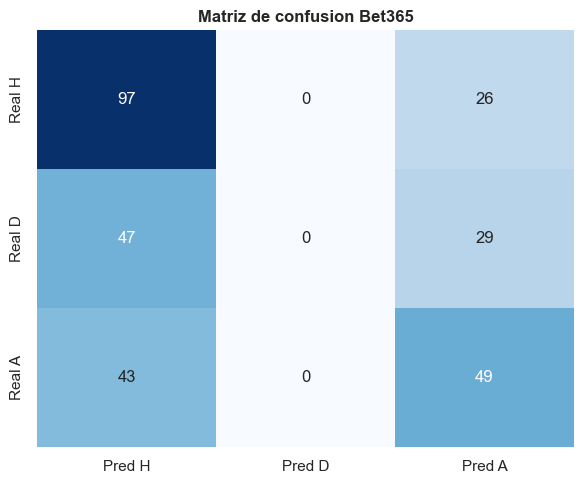

,Pred H,Pred D,Pred A
Real H,97,0,26
Real D,47,0,29
Real A,43,0,49


In [29]:
if "bet365_pred" in match_eda.columns:
    labels = ["H", "D", "A"]
    cm = confusion_matrix(match_eda["ftr"], match_eda["bet365_pred"], labels=labels)
    cm_df = pd.DataFrame(cm, index=[f"Real {x}" for x in labels], columns=[f"Pred {x}" for x in labels])
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax)
    ax.set_title("Matriz de confusion Bet365")
    plt.tight_layout()
    plt.show()
    display(cm_df)
else:
    warnings.warn("No hay prediccion Bet365 para matriz de confusion.")

**Insight accionable:** esta matriz define el benchmark operativo del Match Predictor. Si el modelo propio mejora solo una clase pero empeora mucho otra, el accuracy agregado puede ocultar problemas.

## 6. Variables con riesgo de data leakage

Las variables como tiros, tiros a puerta, corners, faltas, tarjetas y goles observados describen lo que ya paso en el partido. Usarlas directamente para predecir ese mismo partido es data leakage. Para prediccion real solo se usan datos conocidos antes del inicio o historiales previos calculados con `shift(1)`.

In [30]:
leakage_table = pd.DataFrame(
    [
        {"feature_family": "Odds prepartido", "examples": "b365h, b365d, b365a, bwh, bwd, bwa", "classification": "Feature pre-partido valida", "reason": "Disponible antes del kickoff."},
        {"feature_family": "Identidad de equipos", "examples": "home_team, away_team", "classification": "Feature pre-partido valida", "reason": "Se conoce antes del partido; requiere encoding."},
        {"feature_family": "Arbitro", "examples": "referee, ref_avg_yellows_last10", "classification": "Feature pre-partido valida", "reason": "El arbitro se conoce antes; sus promedios deben usar partidos previos."},
        {"feature_family": "Ratings previos", "examples": "team ratings, forma previa", "classification": "Feature pre-partido valida", "reason": "Valida si se calcula con informacion anterior al partido."},
        {"feature_family": "Rolling averages previos", "examples": "rolling_home_goals_for_last5, rolling_away_points_last5", "classification": "Feature pre-partido valida", "reason": "Usan shift(1), no incluyen el partido actual."},
        {"feature_family": "Goles finales", "examples": "fthg, ftag, total_goals, goal_diff", "classification": "Post-partido no valida", "reason": "Son targets o derivadas directas del resultado."},
        {"feature_family": "Tiros y tiros a puerta", "examples": "hs, as_, hst, ast", "classification": "Post-partido no valida", "reason": "Se observan durante/despues del partido."},
        {"feature_family": "Corners", "examples": "hc, ac", "classification": "Post-partido no valida", "reason": "Describen eventos del partido actual."},
        {"feature_family": "Faltas y tarjetas", "examples": "hf, af, hy, ay, hr, ar", "classification": "Post-partido no valida", "reason": "No estan disponibles antes del partido."},
    ]
)
display(leakage_table)

,feature_family,examples,classification,reason
0,Odds prepartido,"b365h, b365d, b365a, bwh, bwd, bwa",Feature pre-partido valida,Disponible antes del kickoff.
1,Identidad de equipos,"home_team, away_team",Feature pre-partido valida,Se conoce antes del partido; requiere encoding.
2,Arbitro,"referee, ref_avg_yellows_last10",Feature pre-partido valida,El arbitro se conoce antes; sus promedios debe...
3,Ratings previos,"team ratings, forma previa",Feature pre-partido valida,Valida si se calcula con informacion anterior ...
4,Rolling averages previos,"rolling_home_goals_for_last5, rolling_away_poi...",Feature pre-partido valida,"Usan shift(1), no incluyen el partido actual."
5,Goles finales,"fthg, ftag, total_goals, goal_diff",Post-partido no valida,Son targets o derivadas directas del resultado.
6,Tiros y tiros a puerta,"hs, as_, hst, ast",Post-partido no valida,Se observan durante/despues del partido.
7,Corners,"hc, ac",Post-partido no valida,Describen eventos del partido actual.
8,Faltas y tarjetas,"hf, af, hy, ay, hr, ar",Post-partido no valida,No estan disponibles antes del partido.


**Insight accionable:** el dataset de entrenamiento del Match Predictor debe separar targets y variables ex post. Las stats del partido pueden servir para analisis descriptivo, pero solo entran al predictor si se transforman en historial previo.

## 7. Feature engineering para Match Predictor

Se calculan features prepartido usando solo informacion anterior. Cada equipo se ordena por fecha y las ventanas rolling usan `shift(1)` para excluir el partido actual.

In [31]:
def build_rolling_match_features(matches_df: pd.DataFrame, window: int = 5) -> tuple[pd.DataFrame, pd.DataFrame]:
    required = ["id", "kickoff", "home_team", "away_team", "fthg", "ftag", "ftr"]
    missing = warn_missing(matches_df, required, "matches para rolling")
    if missing:
        return matches_df.copy(), pd.DataFrame()

    base = matches_df.sort_values(["kickoff", "id"]).copy()

    home_rows = base[["id", "kickoff", "home_team", "fthg", "ftag", "ftr"]].copy()
    home_rows.columns = ["match_id", "kickoff", "team", "goals_for", "goals_against", "ftr"]
    home_rows["venue"] = "home"
    home_rows["points"] = np.select([home_rows["ftr"].eq("H"), home_rows["ftr"].eq("D")], [3, 1], default=0)
    home_rows["win"] = home_rows["ftr"].eq("H").astype(int)

    away_rows = base[["id", "kickoff", "away_team", "ftag", "fthg", "ftr"]].copy()
    away_rows.columns = ["match_id", "kickoff", "team", "goals_for", "goals_against", "ftr"]
    away_rows["venue"] = "away"
    away_rows["points"] = np.select([away_rows["ftr"].eq("A"), away_rows["ftr"].eq("D")], [3, 1], default=0)
    away_rows["win"] = away_rows["ftr"].eq("A").astype(int)

    team_history = pd.concat([home_rows, away_rows], ignore_index=True)
    team_history = team_history.sort_values(["team", "kickoff", "match_id"]).reset_index(drop=True)

    grouped = team_history.groupby("team", group_keys=False)
    team_history[f"rolling_goals_for_last{window}"] = grouped["goals_for"].transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
    team_history[f"rolling_goals_against_last{window}"] = grouped["goals_against"].transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())
    team_history[f"rolling_points_last{window}"] = grouped["points"].transform(lambda s: s.shift(1).rolling(window, min_periods=1).sum())
    team_history[f"rolling_win_rate_last{window}"] = grouped["win"].transform(lambda s: s.shift(1).rolling(window, min_periods=1).mean())

    rolling_cols = [
        f"rolling_goals_for_last{window}",
        f"rolling_goals_against_last{window}",
        f"rolling_points_last{window}",
        f"rolling_win_rate_last{window}",
    ]

    home_features = team_history.loc[team_history["venue"] == "home", ["match_id", *rolling_cols]].rename(
        columns={
            "match_id": "id",
            f"rolling_goals_for_last{window}": f"rolling_home_goals_for_last{window}",
            f"rolling_goals_against_last{window}": f"rolling_home_goals_against_last{window}",
            f"rolling_points_last{window}": f"rolling_home_points_last{window}",
            f"rolling_win_rate_last{window}": f"rolling_home_win_rate_last{window}",
        }
    )
    away_features = team_history.loc[team_history["venue"] == "away", ["match_id", *rolling_cols]].rename(
        columns={
            "match_id": "id",
            f"rolling_goals_for_last{window}": f"rolling_away_goals_for_last{window}",
            f"rolling_goals_against_last{window}": f"rolling_away_goals_against_last{window}",
            f"rolling_points_last{window}": f"rolling_away_points_last{window}",
            f"rolling_win_rate_last{window}": f"rolling_away_win_rate_last{window}",
        }
    )

    features = base.merge(home_features, on="id", how="left").merge(away_features, on="id", how="left")
    features[f"rolling_goals_for_diff_last{window}"] = features[f"rolling_home_goals_for_last{window}"] - features[f"rolling_away_goals_for_last{window}"]
    features[f"rolling_goals_against_diff_last{window}"] = features[f"rolling_home_goals_against_last{window}"] - features[f"rolling_away_goals_against_last{window}"]
    features[f"rolling_points_diff_last{window}"] = features[f"rolling_home_points_last{window}"] - features[f"rolling_away_points_last{window}"]
    features[f"rolling_win_rate_diff_last{window}"] = features[f"rolling_home_win_rate_last{window}"] - features[f"rolling_away_win_rate_last{window}"]

    return features, team_history


matches_features, team_history = build_rolling_match_features(match_eda, window=5)

if all(col in matches_features.columns for col in odds_cols):
    for col in odds_cols:
        matches_features[col] = pd.to_numeric(matches_features[col], errors="coerce")
    matches_features["b365_home_prob"] = 1 / matches_features["b365h"]
    matches_features["b365_draw_prob"] = 1 / matches_features["b365d"]
    matches_features["b365_away_prob"] = 1 / matches_features["b365a"]
    prob_sum = matches_features[["b365_home_prob", "b365_draw_prob", "b365_away_prob"]].sum(axis=1)
    matches_features["b365_home_prob_norm"] = matches_features["b365_home_prob"] / prob_sum
    matches_features["b365_draw_prob_norm"] = matches_features["b365_draw_prob"] / prob_sum
    matches_features["b365_away_prob_norm"] = matches_features["b365_away_prob"] / prob_sum
    matches_features["market_favorite_strength"] = matches_features[["b365_home_prob_norm", "b365_draw_prob_norm", "b365_away_prob_norm"]].max(axis=1)

rolling_features_created = [
    "rolling_home_goals_for_last5",
    "rolling_home_goals_against_last5",
    "rolling_away_goals_for_last5",
    "rolling_away_goals_against_last5",
    "rolling_home_points_last5",
    "rolling_away_points_last5",
    "rolling_home_win_rate_last5",
    "rolling_away_win_rate_last5",
]

display(matches_features[["id", "kickoff", "home_team", "away_team", "ftr", *rolling_features_created]].head(12))

,id,kickoff,home_team,away_team,ftr,rolling_home_goals_for_last5,rolling_home_goals_against_last5,rolling_away_goals_for_last5,rolling_away_goals_against_last5,rolling_home_points_last5,rolling_away_points_last5,rolling_home_win_rate_last5,rolling_away_win_rate_last5
0,1,2025-08-15 20:00:00,Liverpool,Bournemouth,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2025-08-16 12:30:00,Aston Villa,Newcastle,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2025-08-16 15:00:00,Brighton,Fulham,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,4,2025-08-16 15:00:00,Sunderland,West Ham,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2025-08-16 15:00:00,Tottenham,Burnley,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,6,2025-08-16 17:30:00,Wolves,Man City,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,7,2025-08-17 14:00:00,Chelsea,Crystal Palace,D,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,8,2025-08-17 14:00:00,Nottingham Forest,Brentford,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,9,2025-08-17 16:30:00,Man United,Arsenal,A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10,2025-08-18 20:00:00,Leeds,Everton,H,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**Insight accionable:** las primeras fechas pueden quedar con nulos porque no existe historial previo. Eso es correcto: imputar o recortar esas filas se decide en entrenamiento, pero no se debe usar informacion del partido actual para llenarlas.

## 8. Correlaciones y seleccion preliminar de features

Se revisan correlaciones entre variables numericas prepartido, su relacion con `total_goals`, posibles senales para clasificacion `H/D/A` y variables redundantes.

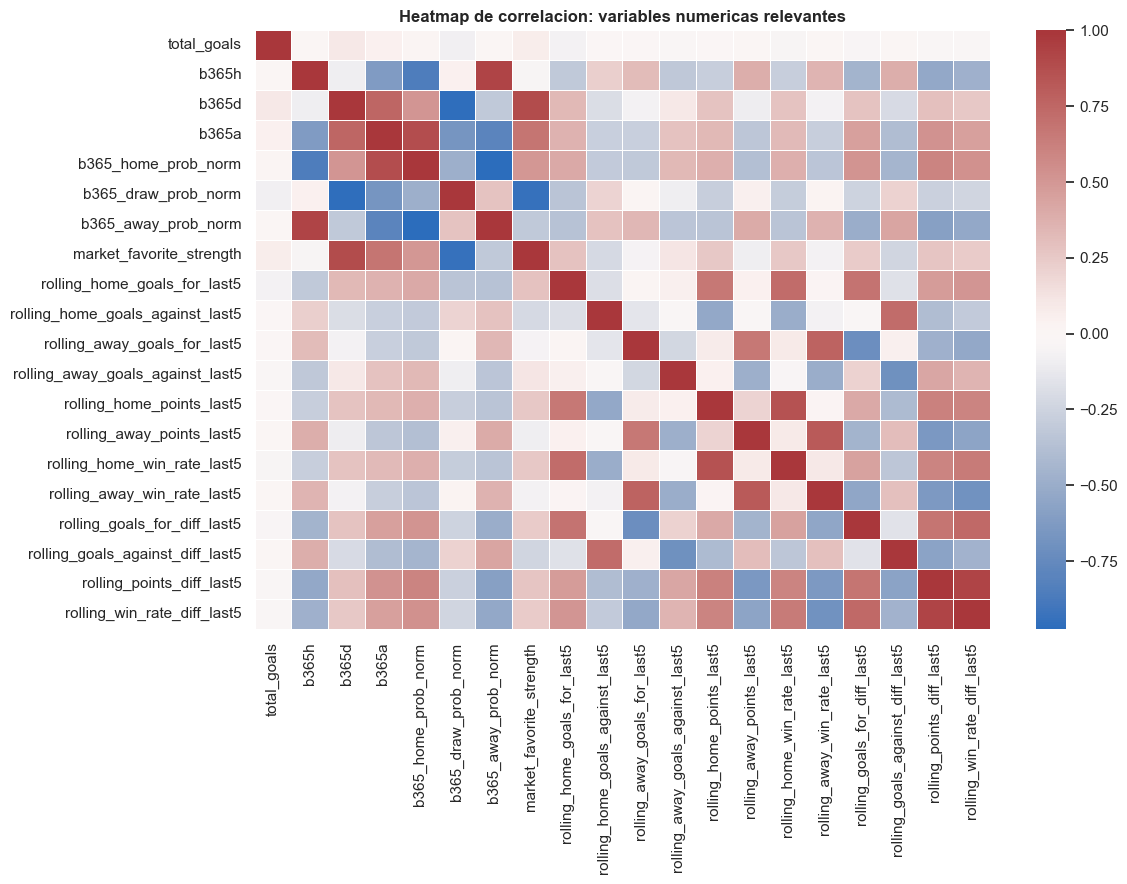

In [32]:
correlation_candidates = [
    "total_goals",
    "b365h", "b365d", "b365a",
    "b365_home_prob_norm", "b365_draw_prob_norm", "b365_away_prob_norm", "market_favorite_strength",
    *rolling_features_created,
    "rolling_goals_for_diff_last5", "rolling_goals_against_diff_last5", "rolling_points_diff_last5", "rolling_win_rate_diff_last5",
]
correlation_cols = [col for col in correlation_candidates if col in matches_features.columns]
numeric_corr_df = matches_features[correlation_cols].apply(pd.to_numeric, errors="coerce")
corr = numeric_corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, cmap="vlag", center=0, linewidths=0.4, ax=ax)
ax.set_title("Heatmap de correlacion: variables numericas relevantes")
plt.tight_layout()
plt.show()

**Insight accionable:** las odds e probabilidades implicitas suelen estar fuertemente correlacionadas entre si. Para modelos lineales conviene evitar duplicados extremos o usar regularizacion.

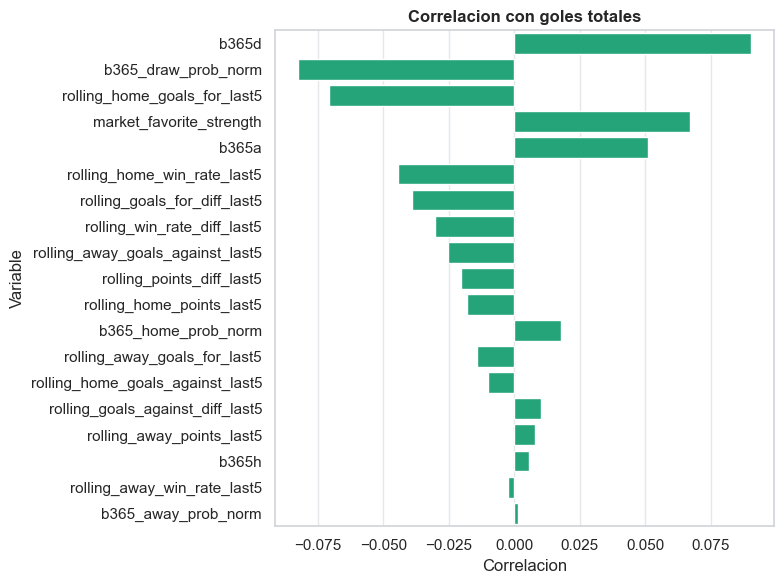

,corr_with_total_goals
b365d,0.090507
b365_draw_prob_norm,-0.082674
rolling_home_goals_for_last5,-0.070898
market_favorite_strength,0.067013
b365a,0.050864
rolling_home_win_rate_last5,-0.044527
rolling_goals_for_diff_last5,-0.038996
rolling_win_rate_diff_last5,-0.030379
rolling_away_goals_against_last5,-0.025264
rolling_points_diff_last5,-0.020427


In [33]:
if "total_goals" in corr.columns:
    corr_total = (
        corr["total_goals"]
        .drop(labels=["total_goals"], errors="ignore")
        .dropna()
        .sort_values(key=lambda s: s.abs(), ascending=False)
        .to_frame("corr_with_total_goals")
    )
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.barplot(data=corr_total.reset_index(), y="index", x="corr_with_total_goals", color=COLORS["emerald"], ax=ax)
    ax.set_title("Correlacion con goles totales")
    ax.set_xlabel("Correlacion")
    ax.set_ylabel("Variable")
    plt.tight_layout()
    plt.show()
    display(corr_total)

**Insight accionable:** las correlaciones con `total_goals` ayudan a seleccionar variables para la regresion lineal, pero deben interpretarse con cautela porque la muestra de partidos es pequena.

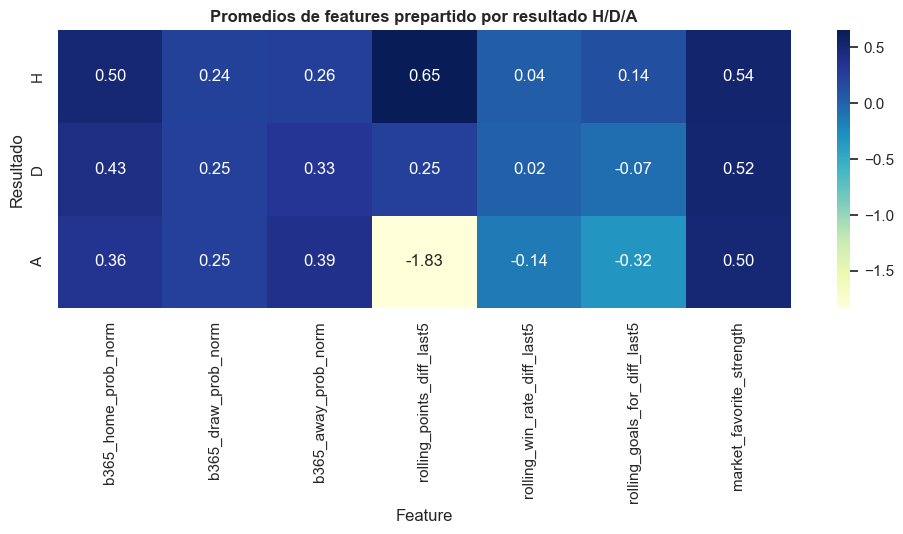

,b365_home_prob_norm,b365_draw_prob_norm,b365_away_prob_norm,rolling_points_diff_last5,rolling_win_rate_diff_last5,rolling_goals_for_diff_last5,market_favorite_strength
ftr,,,,,,,
H,0.499612,0.239576,0.260811,0.652542,0.039689,0.142514,0.539384
D,0.425405,0.245199,0.329396,0.246575,0.017123,-0.071918,0.519123
A,0.355658,0.254185,0.390157,-1.833333,-0.139444,-0.320185,0.499003


In [34]:
classification_features = [
    "b365_home_prob_norm", "b365_draw_prob_norm", "b365_away_prob_norm",
    "rolling_points_diff_last5", "rolling_win_rate_diff_last5", "rolling_goals_for_diff_last5",
    "market_favorite_strength",
]
classification_features = [col for col in classification_features if col in matches_features.columns]
class_signal = matches_features.groupby("ftr")[classification_features].mean().reindex(["H", "D", "A"])

fig, ax = plt.subplots(figsize=(10, 5.5))
sns.heatmap(class_signal, annot=True, fmt=".2f", cmap="YlGnBu", ax=ax)
ax.set_title("Promedios de features prepartido por resultado H/D/A")
ax.set_xlabel("Feature")
ax.set_ylabel("Resultado")
plt.tight_layout()
plt.show()
display(class_signal)

**Insight accionable:** las diferencias local-visitante de forma y las probabilidades de mercado parecen mas utiles para clasificacion que los niveles absolutos. Estas variables son candidatas para la regresion logistica multiclase.

In [35]:
upper = corr.abs().where(np.triu(np.ones(corr.shape), k=1).astype(bool))
redundant_pairs = (
    upper.stack()
    .sort_values(ascending=False)
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
)
redundant_pairs = redundant_pairs.loc[redundant_pairs["abs_corr"] >= 0.85]
display(redundant_pairs.head(20))

,feature_1,feature_2,abs_corr
0,b365_home_prob_norm,b365_away_prob_norm,0.975075
1,b365d,b365_draw_prob_norm,0.962367
2,b365_draw_prob_norm,market_favorite_strength,0.939554
3,b365h,b365_away_prob_norm,0.930095
4,rolling_points_diff_last5,rolling_win_rate_diff_last5,0.923845
5,b365d,market_favorite_strength,0.889830
6,b365a,b365_home_prob_norm,0.877293
7,rolling_home_points_last5,rolling_home_win_rate_last5,0.858137
8,b365h,b365_home_prob_norm,0.858124


**Insight accionable:** pares con correlacion absoluta mayor a 0.85 son redundantes para modelos lineales simples. Se pueden dejar con regularizacion o seleccionar una sola variable por familia.

## 9. Conclusiones del EDA

- **Modelo xG:** distancia, angulo, `BigChance`, penal, parte del cuerpo y zona del disparo tienen relacion directa con la conversion de tiros.
- **Match Predictor:** las odds de Bet365 son un baseline fuerte; para intentar superarlo se necesitan features de forma previa calculadas sin leakage.
- **Features seleccionadas xG:** `shot_distance`, `shot_angle`, `is_big_chance`, `is_header`, `is_right_foot`, `is_left_foot`, `is_penalty`, `is_volley`, `first_touch`, `from_corner`, `is_counter`.
- **Features seleccionadas Match Predictor:** rolling de goles a favor/en contra, puntos y win rate de local y visitante en los ultimos 5 partidos previos; probabilidades implicitas de Bet365.
- **Riesgos detectados:** desbalance fuerte en xG, muestra pequena de partidos, empates dificiles de separar, odds redundantes y variables post-partido con alto riesgo de leakage.
- **Proximos pasos:** entrenar regresion logistica xG con metricas robustas; entrenar regresion lineal para goles totales y logistica multiclase H/D/A con validacion cruzada; comparar contra Bet365.

## 10. Exportacion de datasets procesados

Se guardan los datasets pedidos por el taller:

- `data/processed/shots_features.csv`
- `data/processed/matches_features.csv`
- `data/processed/eda_summary.json`

In [36]:
shot_export_cols = [
    col for col in [
        "id", "match_id", "minute", "second", "period", "event_type", "outcome", "team_name", "player_name",
        "x", "y", "is_shot", "is_goal", "qualifier_text", "body_part", "shot_zone", *xg_features_created
    ]
    if col in shots.columns
]

match_export_cols = [
    col for col in [
        "id", "date", "time", "kickoff", "home_team", "away_team", "fthg", "ftag", "ftr", "total_goals",
        "b365h", "b365d", "b365a", "b365_home_prob_norm", "b365_draw_prob_norm", "b365_away_prob_norm",
        "market_favorite_strength", *rolling_features_created,
        "rolling_goals_for_diff_last5", "rolling_goals_against_diff_last5", "rolling_points_diff_last5", "rolling_win_rate_diff_last5",
    ]
    if col in matches_features.columns
]

shots_features_path = PROCESSED_DATA_DIR / "shots_features.csv"
matches_features_path = PROCESSED_DATA_DIR / "matches_features.csv"
eda_summary_path = PROCESSED_DATA_DIR / "eda_summary.json"

shots[shot_export_cols].to_csv(shots_features_path, index=False)
matches_features[match_export_cols].to_csv(matches_features_path, index=False)

summary_features = xg_features_created + rolling_features_created
if all(col in matches_features.columns for col in ["b365_home_prob_norm", "b365_draw_prob_norm", "b365_away_prob_norm"]):
    summary_features += ["b365_home_prob_norm", "b365_draw_prob_norm", "b365_away_prob_norm", "market_favorite_strength"]

eda_summary = {
    "total_matches": int(len(match_eda)),
    "total_events": int(len(events_clean)),
    "total_shots": int(len(shots)),
    "total_goals": int(match_eda["total_goals"].sum()) if "total_goals" in match_eda.columns else int(shots["is_goal"].sum()),
    "total_shot_goals": int(shots["is_goal"].sum()),
    "shot_conversion_rate": float(shots["is_goal"].mean()) if len(shots) else None,
    "xg_naive_baseline_accuracy": float(1 - shots["is_goal"].mean()) if len(shots) else None,
    "home_win_rate": float((match_eda["ftr"] == "H").mean()) if "ftr" in match_eda.columns else None,
    "draw_rate": float((match_eda["ftr"] == "D").mean()) if "ftr" in match_eda.columns else None,
    "away_win_rate": float((match_eda["ftr"] == "A").mean()) if "ftr" in match_eda.columns else None,
    "bet365_accuracy": bet365_accuracy,
    "features_created": summary_features,
}

with eda_summary_path.open("w", encoding="utf-8") as file:
    json.dump(eda_summary, file, ensure_ascii=True, indent=2)

print(f"Exportado: {shots_features_path.relative_to(PROJECT_ROOT)}")
print(f"Exportado: {matches_features_path.relative_to(PROJECT_ROOT)}")
print(f"Exportado: {eda_summary_path.relative_to(PROJECT_ROOT)}")
display(pd.DataFrame([eda_summary]).T.rename(columns={0: "value"}))

Exportado: data\processed\shots_features.csv
Exportado: data\processed\matches_features.csv
Exportado: data\processed\eda_summary.json


,value
total_matches,291
total_events,444252
total_shots,7198
total_goals,807
total_shot_goals,807
shot_conversion_rate,0.112114
xg_naive_baseline_accuracy,0.887886
home_win_rate,0.42268
draw_rate,0.261168
away_win_rate,0.316151


**Insight accionable:** estos exports dejan una frontera clara entre exploracion y entrenamiento. Los modelos pueden consumir `shots_features.csv` y `matches_features.csv` sin recalcular todo el EDA.